In [1]:
import pandas as pd
import numpy as np
import gsw
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
def round_off(series):
    return round(series * 2) / 2

def customround(series, base=5):
    return base * round(series/base)

In [3]:
f5906484 = pd.read_csv("5906484qcno2.txt",skiprows = 70, sep='\t',
    parse_dates = ['mon/day/yr'], na_values = [-10000000000.0])
# add 'month' column so we can match gridded WOA data
f5906484['month'] = f5906484['mon/day/yr'].dt.strftime('%m')
f5906484['month'] = f5906484['month'].astype(int)
f5906484 =  f5906484[ f5906484['Nitrite[µmol/kg]'] > 0]

data = f5906484

data['depth'] = customround(data['Depth[m]'])
data['lon'] = round(data['Lon [°E]']) + 0.5 #round_off(data['Lon [°E]'])
data['lon'] = data['lon'] - 360.0
data['lat'] = round(data['Lat [°N]']) + 0.5 #round_off(data['Lat [°N]'])


def process_WOA(month):
    if i<10:
        link = f'https://www.ncei.noaa.gov/thredds-ocean/dodsC/ncei/woa/phosphate/all/1.00/woa18_all_p0{month}_01.nc'
    elif i>=10:
        link = f'https://www.ncei.noaa.gov/thredds-ocean/dodsC/ncei/woa/phosphate/all/1.00/woa18_all_p{month}_01.nc'
    ds = xr.open_dataset(link, decode_times = False)
    ds = ds.sel(lat = slice(16,19),lon = slice(-110, -106))
    df = ds.to_dataframe(dim_order = ['lat', 'nbounds', 'lon', 'depth', 'time'])
    df = df.reset_index().set_index('depth')
    indexdf = pd.DataFrame(np.arange(0,805,5), columns = ['depth']).set_index('depth')
    monthlydf = pd.DataFrame([])
    for lat in df.lat.drop_duplicates():
        for lon in df.lon.drop_duplicates():
            subset = df[(df.lat == lat) & (df.lon ==lon)]
            temp = indexdf.join(subset)
            temp = temp.ffill(axis=0)
            temp['lat'] = lat
            temp['lon'] = lon
            monthlydf = pd.concat([monthlydf, temp])
    monthlydf = monthlydf.reset_index()
    monthlydf = monthlydf[['lat','lon','depth','p_an']].groupby(['lat','lon','depth']).mean()
    monthlydf['month'] = month
    return monthlydf

data = data.set_index(['month','lat','lon','depth'])

WOA = pd.DataFrame()

for i in range(1,13):
    print(i)
    monthlyWOA = process_WOA(i)
    WOA = pd.concat([WOA, monthlyWOA])

WOA = WOA.reset_index()
WOA = WOA.set_index(['month','lat','lon','depth'])

data = data.join(WOA)
print(data['p_an'].head())

1
2
3
4
5
6
7
8
9
10
11
12
month  lat   lon     depth
1      17.5  -107.5  110.0    2.116911
                     120.0    2.116911
                     130.0    2.412905
                     140.0    2.412905
                     150.0    2.505203
Name: p_an, dtype: float32


In [4]:
f5906484 = data.reset_index()
cols = {
    'Station': "station",
    #"CASTNO": "cast",
    #'Lat [°N]': "lat",
    #'Lon [°E]': "lon",
    'Pressure[dbar]': "press",
    'Temperature[°C]': "temperature",
    'Salinity[pss]': "sal",
    'QF.3': "sal_flag",
    'Oxygen[µmol/kg]': "O2",
    'QF.6': "O2_flag",
    'Nitrate[µmol/kg]':"NO3",
    'QF.8':'NO3_flag',
    'Nitrite[µmol/kg]': "NO2",
    'QF.17': "NO2_flag",
    'p_an': "phosphate",
    #"PHSPHT_FLAG_W": "phosphate_flag",
    #"NH4_FLAG_W": "NH4_flag",
    'pHinsitu[Total]': "pH_insitu",
    'QF.12': "pH_tot_flag",
    'TALK_LIAR[µmol/kg]':'TA',
    'QF.14':"TA_flag",
    'DIC_LIAR[µmol/kg]':'DIC',
    'QF.15':'DIC_flag'
}
f5906484 = f5906484.rename(columns=cols)

# Select Flagged Bad Data

flag_good = np.array([0]) # WHAT ARE THE QUALITY FLAGS FOR THESE DATA
idx_flag = np.where(
    (np.isin(f5906484["sal_flag"], flag_good))
    & (np.isin(f5906484["O2_flag"], flag_good))
    & (np.isin(f5906484["NO3_flag"], flag_good))
    #& (np.isin(f5906484["phosphate_flag"], flag_good))
    #& (np.isin(f5906484["NH4_flag"], flag_good))
    & (np.isin(f5906484["pH_tot_flag"], flag_good))
    & (np.isin(f5906484["TA_flag"], flag_good))
    & (np.isin(f5906484["NO2_flag"], flag_good))
)

# Calculate Density
SA = gsw.SA_from_SP(f5906484["sal"], f5906484["press"], f5906484["lon"], f5906484["lat"])
CT = gsw.CT_from_t(SA, f5906484["temperature"], f5906484["press"])
f5906484["sigma0"] = gsw.density.sigma0(SA, CT)
f5906484["rho"] = gsw.density.rho(SA, CT, f5906484["press"])

f5906484["Nstar"] = ((f5906484.NO2 + f5906484.NO3) - 16 * f5906484.phosphate + 2.9)

In [5]:
f5906484.columns

Index(['month', 'lat', 'lon', 'depth', 'Cruise', 'station', 'Type',
       'mon/day/yr', 'hh:mm', 'Lon [°E]', 'Lat [°N]', 'QF', 'press', 'QF.1',
       'temperature', 'QF.2', 'sal', 'sal_flag', 'Sigma_theta[kg/m^3]', 'QF.4',
       'Depth[m]', 'QF.5', 'O2', 'O2_flag', 'OxygenSat[%]', 'QF.7', 'NO3',
       'NO3_flag', 'Chl_a[mg/m^3]', 'QF.9', 'b_bp700[1/m]', 'QF.10',
       'POC[mmol/m^3]', 'QF.11', 'pH_insitu', 'pH_tot_flag', 'pH25C[Total]',
       'QF.13', 'TA', 'TA_flag', 'DIC', 'DIC_flag', 'pCO2_LIAR[µatm]', 'QF.16',
       'NO2', 'NO2_flag', 'phosphate', 'sigma0', 'rho', 'Nstar'],
      dtype='object')

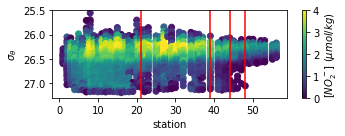

In [15]:
fig, ax = plt.subplots(1,1, figsize = (5,2))

cax = ax.scatter(f5906484['station'],
           f5906484['sigma0'],
            #f5906484['Depth[m]'],
           c = f5906484['NO2'])
cbar = fig.colorbar(cax).set_label('$[NO_2^-]\ (\mu mol/kg$)')
cax.set_clim([0,4.0])

ax.set_ylim([27.3,25.5])
#ax.set_ylim([2000,0])

ax.axvline(21, color = "r")
ax.axvline(39, color = "r")
ax.axvline(44, color = "r")
ax.axvline(48, color = "r")

ax.set_xlabel("station")
ax.set_ylabel(r"$\sigma_{\theta}$")
plt.tight_layout()
plt.savefig("figures/no2section.pdf")

In [50]:
densities = []
for s in f5906484['station'].drop_duplicates():
    temp = f5906484[f5906484['station']==s]
    no2maxdensity = float(np.mean(temp[temp['NO2']==temp.NO2.max()]['sigma0']))
    print(f"station:{s} SNM density:{no2maxdensity}")
    densities.append(no2maxdensity)

station:2 SNM density:26.339821655150445
station:1 SNM density:26.56514973796743
station:37 SNM density:26.20231575938965
station:36 SNM density:26.242509450872603
station:35 SNM density:26.274973374589308
station:39 SNM density:26.252809135163943
station:3 SNM density:26.332654054625664
station:5 SNM density:26.560358647582234
station:4 SNM density:26.47125080693104
station:42 SNM density:26.267406675258826
station:43 SNM density:26.33953664589717
station:41 SNM density:26.380263137426482
station:8 SNM density:26.288269608515293
station:7 SNM density:26.26536273939655
station:6 SNM density:26.498299461591387
station:44 SNM density:26.302794941624597
station:45 SNM density:26.270749767359348
station:46 SNM density:26.318806560793064
station:9 SNM density:26.350311631485738
station:11 SNM density:26.308841200568395
station:10 SNM density:26.383164031357182
station:47 SNM density:26.32799734161381
station:49 SNM density:26.25460633015041
station:48 SNM density:26.25310794451616
station:1

In [51]:
np.mean(densities)

26.312253769457374

/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_6791/250066865.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(1,1, figsize = (3,4))


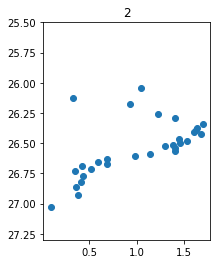

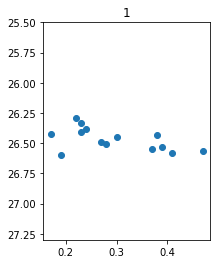

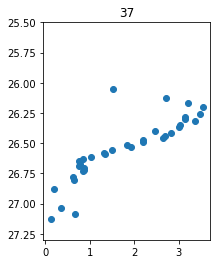

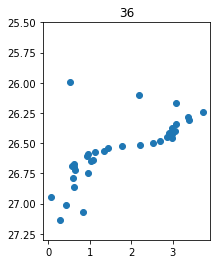

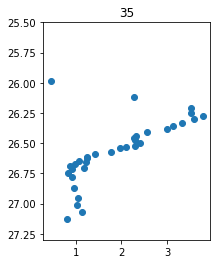

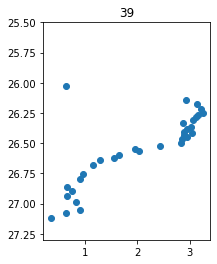

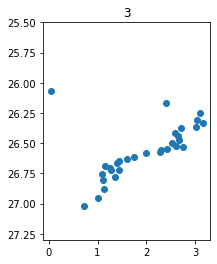

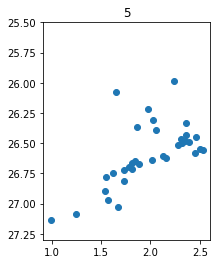

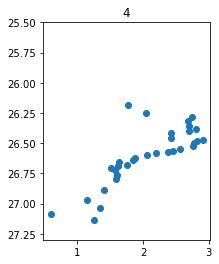

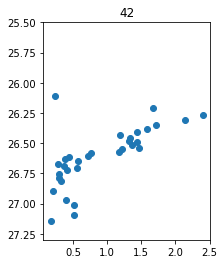

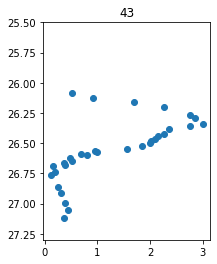

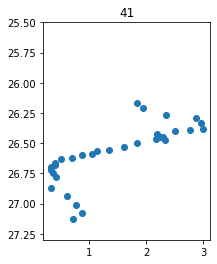

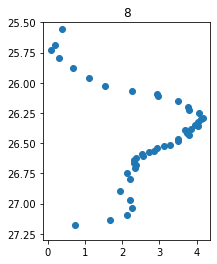

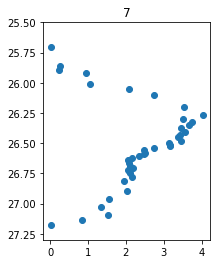

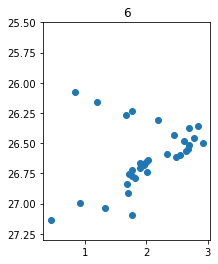

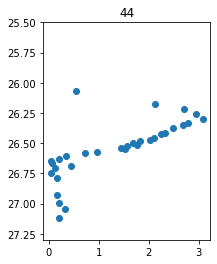

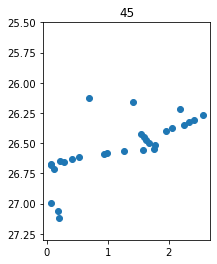

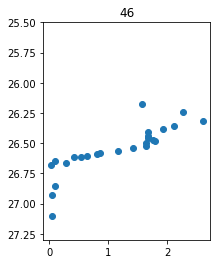

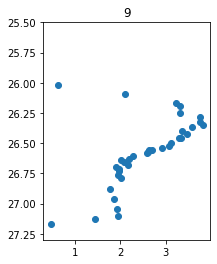

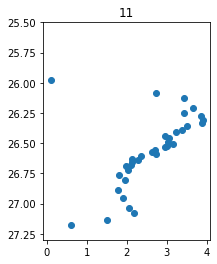

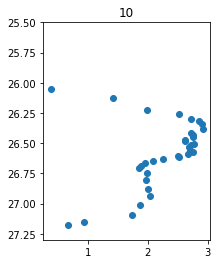

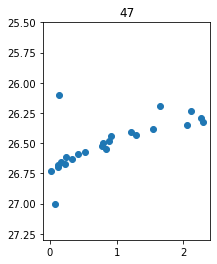

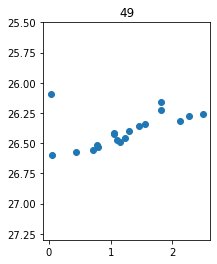

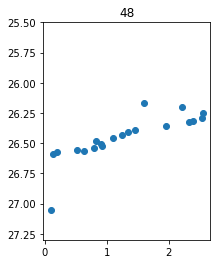

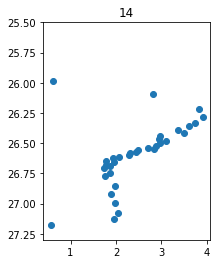

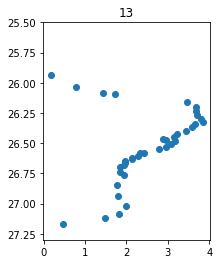

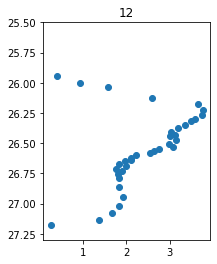

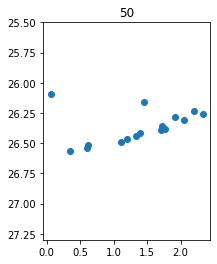

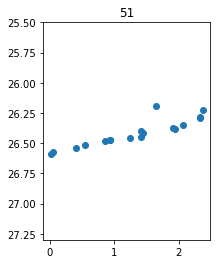

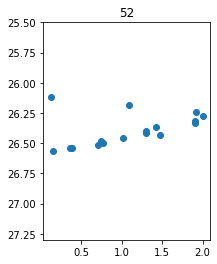

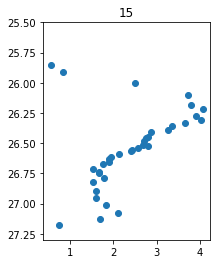

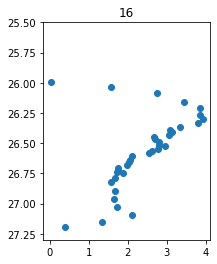

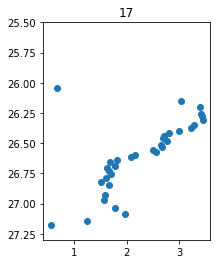

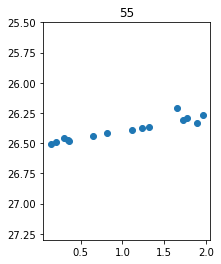

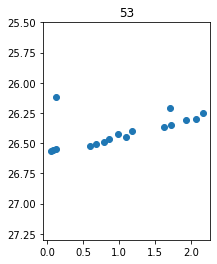

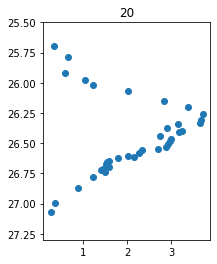

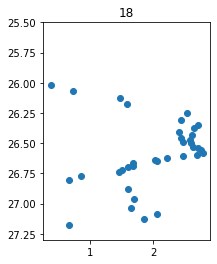

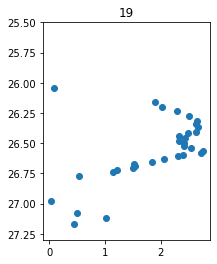

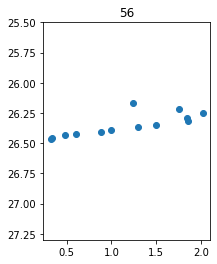

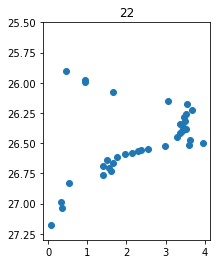

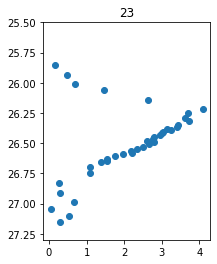

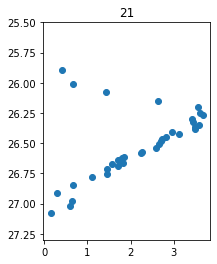

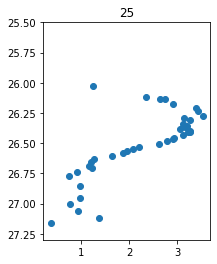

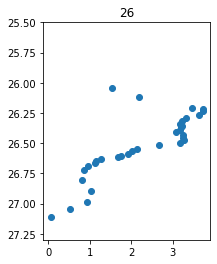

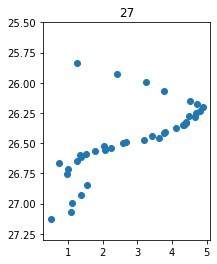

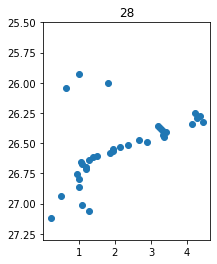

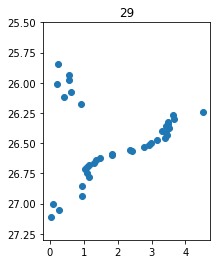

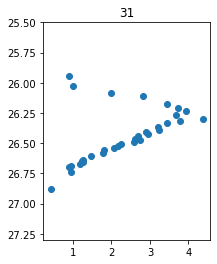

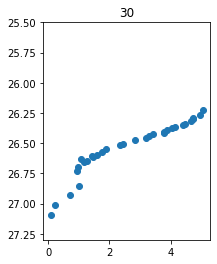

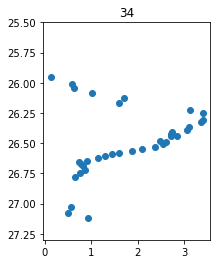

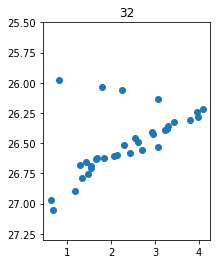

In [53]:
for s in f5906484['station'].drop_duplicates():
    temp = f5906484[f5906484['station']==s]
    fig, ax = plt.subplots(1,1, figsize = (3,4))
    ax.scatter(temp.NO2,
               temp['sigma0']
              )
    ax.set_ylim([27.3,25.5])
    ax.set_title(f"{s}")